In [1]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
from probeinterface import write_probeinterface, read_probeinterface
import spikeinterface.exporters as sexp
from spikeinterface.core import write_binary_recording
from pathlib import Path
import pickle
from tabnanny import verbose
import spikeinterface as si
import numpy as np
from spikeinterface.core import get_template_extremum_channel
import scipy.spatial.distance
from scipy.sparse.csgraph import connected_components
import pickle
import pandas as pd
from utils_clique import (
    CliqueInfo,
    build_shank_cliques,
    neuron_inf_dict_to_dataframe,
    get_recording_clique,
    filter_neuron_inf_by_clique,
    filter_gt_detect_array_by_clique,
    prepare_training_data,
    train_autosort_model,
    build_sliding_cliques
)

files = sorted(os.listdir("/media/ubuntu/sda/data/mouse6/ns4/natural_image"))
recording_list = []
for file in files:
    recording_raw = se.read_blackrock(file_path=f'/media/ubuntu/sda/data/mouse6/ns4/natural_image/{file}')
    recording_recorded = recording_raw.remove_channels(["98", '31', '32'])
    recording_list.append(recording_recorded)


probe_30channel = read_probeinterface('/media/ubuntu/sda/data/probe.json')
recording_recorded = si.concatenate_recordings(recording_list)
recording_recorded = recording_recorded.set_probegroup(probe_30channel)

recording_cmr = recording_recorded
recording_f = spre.bandpass_filter(recording_recorded, freq_min=300, freq_max=3000)
recording_recorded = spre.notch_filter(recording_f, freq=60)

print(recording_f)
recording_cmr = spre.common_reference(recording_f, reference="global", operator="median")
recording_cmr = recording_cmr.rename_channels(['A-000', 'A-001', 'A-002', 'A-003', 'A-004',
                               'A-005', 'A-006', 'A-007', 'A-008', 'A-009',
                               'A-0010', 'A-011', 'A-012', 'A-013', 'A-014',
                               'A-015', 'A-016', 'A-017', 'A-018', 'A-019',
                               'A-020', 'A-021', 'A-022', 'A-023', 'A-024',
                               'A-025', 'A-026', 'A-027', 'A-028', 'A-029'])
print(recording_cmr)


/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BandpassFilterRecording: 30 channels - 10000.0Hz - 1 segments - 437,380,586 samples 
                         43,738.06s (12.15 hours) - int16 dtype - 24.44 GiB
ChannelSliceRecording: 30 channels - 10000.0Hz - 1 segments - 437,380,586 samples 
                       43,738.06s (12.15 hours) - int16 dtype - 24.44 GiB


In [2]:
# 从sorting.ipynb获取recording和session信息
# 假设这些变量已经在之前的cell中定义：
# files, recording_list, recording_cmr, recording_f, probe_30channel

# 设置输出文件夹（与sorting.ipynb中的output_folder一致）
output_folder = '/media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim_full'

# 获取probe（从recording_cmr）
probe = recording_cmr.get_probe()
probe.set_contact_ids(recording_cmr.channel_ids)

# 对于30通道，创建一个包含所有通道的clique
probe_df = probe.to_dataframe()
all_channel_ids = probe_df['contact_ids'].astype(str).tolist()
cliques = [
    CliqueInfo(
        clique_id=0,
        device_channel_indices=list(range(len(all_channel_ids))),
        contact_ids=all_channel_ids,
        center=(probe_df['x'].mean(), probe_df['y'].mean())
    )
]

clique_info = {
    'cliques': cliques,  # List of CliqueInfo objects
    'clique_params': {
        'method': 'single_clique_all_channels',
    },
    'probe_df': probe.to_dataframe(),  # Probe dataframe for verification
}

clique_info_path = f'{output_folder}/clique_info.pkl'
with open(clique_info_path, 'wb') as f:
    pickle.dump(clique_info, f)

In [3]:
# 根据recording_list中每个recording的采样点数来计算session范围
# recording是通过concatenate_recordings合并的，合并后只有一个segment
# 需要根据原始recording_list来计算每个session的采样点范围
sampling_frequency = recording_cmr.get_sampling_frequency()

# 计算每个session的采样点范围
segment_sample_ranges = {}  # {segment_idx: (start_sample, end_sample)}
segment_num_samples_dict = {}  # {segment_idx: num_samples}
session_names = []  # 存储每个session的名称

# 获取每个session的文件名（去掉扩展名）
for i, file in enumerate(files):
    # 去掉文件扩展名，作为session名称
    session_name = Path(file).stem
    session_names.append(session_name)

# 根据recording_list中每个recording的采样点数计算范围
current_sample = 0
n_segments = len(recording_list)  # session数量等于recording_list的长度

for seg_idx in range(n_segments):
    # 获取该recording的采样点数（在合并前的原始recording）
    segment_num_samples = recording_list[seg_idx].get_num_samples()
    start_sample = current_sample
    end_sample = current_sample + segment_num_samples
    
    segment_sample_ranges[seg_idx] = (start_sample, end_sample)
    segment_num_samples_dict[seg_idx] = segment_num_samples
    
    session_name = session_names[seg_idx] if seg_idx < len(session_names) else f"session_{seg_idx}"
    print(f"Session {seg_idx} ({session_name}): 采样点范围 = [{start_sample}, {end_sample}), 采样点数 = {segment_num_samples}")
    
    current_sample = end_sample

print(f"\n{'='*60}")
print(f"开始统一处理整个recording的sorting结果")
print(f"{'='*60}\n")

# 设置输出文件夹
combined_output_base = output_folder  # 使用之前定义的output_folder

# 统一的phy_folder路径（整个recording的sorting结果）
phy_folder = f'{combined_output_base}/phy_folder_for_kilosort'

# 读取整个recording的sorting结果
print("读取统一的sorting结果...")
sorting_curated_phy = se.read_phy(phy_folder, exclude_cluster_groups=["noise"])
print(f"读取到 {len(sorting_curated_phy.unit_ids)} 个units\n")

# 对整个recording创建analyzer
print("创建analyzer并计算extensions...")
analyzer_curated_phy = si.create_sorting_analyzer(
    sorting=sorting_curated_phy, 
    recording=recording_cmr,  # 使用common reference后的recording
    format='binary_folder',
    folder=combined_output_base + '/analyzer_curated_temp',
    n_jobs=20, verbose = False
)

extensions_to_compute = [
    "random_spikes",
    "waveforms",
    "templates",
    "unit_locations",
    "template_similarity"
]

extension_params = {
    "unit_locations": {"method": "center_of_mass"},
    "template_similarity": {"method": "cosine_similarity"}
}

analyzer_curated_phy.compute(extensions_to_compute, extension_params=extension_params, n_jobs=20, verbose = False)
print("完成extensions计算\n")

# 获取neuron信息（整个recording）
templates_ext = analyzer_curated_phy.get_extension("templates")
templates_dense = templates_ext.data["average"]
sparsity = analyzer_curated_phy.sparsity
unit_locations_ext = analyzer_curated_phy.get_extension("unit_locations")
unit_locations = unit_locations_ext.get_data()
channel_locations = analyzer_curated_phy.get_channel_locations()

# 处理merge逻辑
if unit_locations.shape[1] >= 2:
    unit_distances = scipy.spatial.distance.cdist(
        unit_locations[:, :2], 
        unit_locations[:, :2], 
        metric="euclidean"
    )
else:
    unit_distances = scipy.spatial.distance.cdist(
        unit_locations, 
        unit_locations, 
        metric="euclidean"
    )

template_similarity_ext = analyzer_curated_phy.get_extension("template_similarity")
template_similarity = template_similarity_ext.get_data()

distance_threshold = 10.0
similarity_threshold = 0.95
num_units = len(analyzer_curated_phy.unit_ids)
pair_mask = np.zeros((num_units, num_units), dtype=bool)

for i in range(num_units):
    for j in range(i + 1, num_units):
        if unit_distances[i, j] < distance_threshold and template_similarity[i, j] > similarity_threshold:
            pair_mask[i, j] = True
            pair_mask[j, i] = True

n_components, labels = connected_components(
    csgraph=pair_mask, 
    directed=False, 
    return_labels=True
)

merge_unit_groups = []
unit_ids_list = analyzer_curated_phy.unit_ids
for component_id in range(n_components):
    unit_indices = np.where(labels == component_id)[0]
    if len(unit_indices) > 1:
        group = [unit_ids_list[i] for i in unit_indices]
        merge_unit_groups.append(group)

# 应用merge（如果有需要merge的units）
if len(merge_unit_groups) > 0:
    print(f"发现 {len(merge_unit_groups)} 组需要merge的units，开始merge...")
    analyzer_merged = analyzer_curated_phy.merge_units(
        merge_unit_groups=merge_unit_groups,
        censor_ms=0.3,
        merging_mode="hard",
        new_id_strategy="append",
        format='binary_folder',
        folder=combined_output_base + '/analyzer_merged',
        verbose=True,
        n_jobs=20
    )
    
    analyzer_merged.compute(extensions_to_compute, extension_params=extension_params, n_jobs=20, verbose = False)
    
    templates_ext_final = analyzer_merged.get_extension("templates")
    templates_dense_final = templates_ext_final.data["average"]
    sparsity_final = analyzer_merged.sparsity
    unit_locations_ext_final = analyzer_merged.get_extension("unit_locations")
    unit_locations_final = unit_locations_ext_final.get_data()
    channel_locations_final = analyzer_merged.get_channel_locations()
    sorting_final = analyzer_merged.sorting
    unit_ids_list_final = analyzer_merged.unit_ids
    
    # 生成position_waveforms
    position_waveforms_final = []
    for unit_id in unit_ids_list_final:
        unit_index = analyzer_merged.sorting.id_to_index(unit_id)
        template_dense_unit = templates_dense_final[unit_index, :, :]
        template_sparse_unit = sparsity_final.sparsify_waveforms(template_dense_unit[np.newaxis, :, :], unit_id)[0]
        sparse_channel_indices = sparsity_final.unit_id_to_channel_indices[unit_id]
        
        if len(sparse_channel_indices) == 0:
            position_waveform = np.zeros(templates_dense_final.shape[1], dtype=templates_dense_final.dtype)
            position_waveforms_final.append(position_waveform)
            continue
        
        sparse_channel_locations = channel_locations_final[sparse_channel_indices, :2]
        unit_location = unit_locations_final[unit_index, :2]
        
        distances = np.sqrt(np.sum((sparse_channel_locations - unit_location[np.newaxis, :])**2, axis=1))
        epsilon = 1e-10
        weights = 1.0 / (distances + epsilon)
        weights = weights / np.sum(weights)
        
        position_waveform = np.dot(template_sparse_unit, weights)
        position_waveforms_final.append(position_waveform)
    
    position_waveforms_final = np.array(position_waveforms_final)
    extremum_channels_final = get_template_extremum_channel(
        analyzer_merged, 
        peak_sign="neg",
        outputs="id"
    )
    
    channel_ids_list = list(analyzer_merged.recording.get_channel_ids())
else:
    print("无需merge units\n")
    # 不需要merge，使用原始结果
    templates_ext_final = analyzer_curated_phy.get_extension("templates")
    templates_dense_final = templates_ext_final.data["average"]
    sparsity_final = analyzer_curated_phy.sparsity
    unit_locations_ext_final = analyzer_curated_phy.get_extension("unit_locations")
    unit_locations_final = unit_locations_ext_final.get_data()
    channel_locations_final = analyzer_curated_phy.get_channel_locations()
    sorting_final = analyzer_curated_phy.sorting
    unit_ids_list_final = unit_ids_list
    
    # 生成position_waveforms
    position_waveforms_final = []
    for unit_id in unit_ids_list_final:
        unit_index = analyzer_curated_phy.sorting.id_to_index(unit_id)
        template_dense_unit = templates_dense_final[unit_index, :, :]
        template_sparse_unit = sparsity_final.sparsify_waveforms(template_dense_unit[np.newaxis, :, :], unit_id)[0]
        sparse_channel_indices = sparsity_final.unit_id_to_channel_indices[unit_id]
        
        if len(sparse_channel_indices) == 0:
            position_waveform = np.zeros(templates_dense_final.shape[1], dtype=templates_dense_final.dtype)
            position_waveforms_final.append(position_waveform)
            continue
        
        sparse_channel_locations = channel_locations_final[sparse_channel_indices, :2]
        unit_location = unit_locations_final[unit_index, :2]
        
        distances = np.sqrt(np.sum((sparse_channel_locations - unit_location[np.newaxis, :])**2, axis=1))
        epsilon = 1e-10
        weights = 1.0 / (distances + epsilon)
        weights = weights / np.sum(weights)
        
        position_waveform = np.dot(template_sparse_unit, weights)
        position_waveforms_final.append(position_waveform)
    
    position_waveforms_final = np.array(position_waveforms_final)
    extremum_channels_final = get_template_extremum_channel(
        analyzer_curated_phy, 
        peak_sign="neg",
        outputs="id"
    )
    
    channel_ids_list = list(analyzer_curated_phy.recording.get_channel_ids())

# 计算每个unit的channel_id（template中值不为0的通道）
# recording的channel_ids已经是probe的contact_ids（已在读取probe时设置）
print("计算每个unit的channel_id...")
channel_ids_dict = {}  # {unit_id: [contact_id1, contact_id2, ...]}
for idx, unit_id in enumerate(unit_ids_list_final):
    unit_index = sorting_final.id_to_index(unit_id)
    template_unit = templates_dense_final[unit_index, :, :]  # (n_samples, n_channels)
    
    # 找到template中值不为0的通道
    non_zero_channels = []
    for ch_idx in range(template_unit.shape[1]):  # 遍历channels（最后一个维度）
        if np.any(template_unit[:, ch_idx] != 0):  # 检查该通道在所有时间点的值
            # recording的channel_id已经是contact_id，直接使用
            contact_id = str(channel_ids_list[ch_idx])
            non_zero_channels.append(contact_id)
    
    channel_ids_dict[unit_id] = non_zero_channels

print(f"完成channel_id计算，共处理{len(channel_ids_dict)}个units\n")

# 计算channel_snr（每个unit的各个channel的SNR）
print("计算channel_snr...")
n_channels = recording_cmr.get_num_channels()

# 计算noise_std（使用前10秒的数据）
duration_samples = int(10 * sampling_frequency)  # 10秒
max_samples = min(duration_samples, recording_cmr.get_num_samples())
traces = recording_cmr.get_traces(start_frame=0, end_frame=max_samples)  # (n_timepoints, n_channels)

noise_std_detect = np.median(np.abs(traces) / 0.6745, axis=0)  # (n_channels,)

all_spike_times = []
all_spike_unit_ids = []
for unit_id in unit_ids_list_final:
    spike_train = sorting_final.get_unit_spike_train(unit_id)
    all_spike_times.extend(spike_train.tolist())
    all_spike_unit_ids.extend([unit_id] * len(spike_train))

n_spikes_total = len(all_spike_times)
n_spikes_sample = min(1000, n_spikes_total)
if n_spikes_sample > 0:
    random_indices = np.random.choice(n_spikes_total, size=n_spikes_sample, replace=False)
    sampled_spike_times = [all_spike_times[i] for i in random_indices]
    sampled_spike_unit_ids = [all_spike_unit_ids[i] for i in random_indices]
else:
    sampled_spike_times = []
    sampled_spike_unit_ids = []

# 提取这些spike的waveform并计算每个channel的负值amplitude
left_sample = 10
right_sample = 20
window_size = left_sample + right_sample

channel_snr_dict = {} 

for unit_id in unit_ids_list_final:
    channel_snr_dict[unit_id] = {}
    unit_spike_times = [st for st, uid in zip(sampled_spike_times, sampled_spike_unit_ids) if uid == unit_id]
    
    if len(unit_spike_times) == 0:
        unit_spike_times = sorting_final.get_unit_spike_train(unit_id).tolist()
        if len(unit_spike_times) > 1000:
            unit_spike_times = np.random.choice(unit_spike_times, size=1000, replace=False).tolist()
    
    unit_waveforms = []  # List of (n_channels, window_size)
    valid_spike_times = []
    
    for spike_time in unit_spike_times:
        start = spike_time - left_sample
        end = spike_time + right_sample

        # recording_cmr合并后只有一个segment，直接使用全局采样点索引
        # 确保索引在有效范围内
        if start < 0:
            start = 0
        if end > recording_cmr.get_num_samples():
            end = recording_cmr.get_num_samples()
        
        waveform = recording_cmr.get_traces(start_frame=start, end_frame=end)  # (n_timepoints, n_channels)
        unit_waveforms.append(waveform)
        valid_spike_times.append(spike_time)
    
    if len(unit_waveforms) == 0:
        continue
    
    unit_waveforms = np.array(unit_waveforms)  # (n_spikes, n_timepoints, n_channels)
    
    spike_time_values = unit_waveforms[:, left_sample, :]  # (n_spikes, n_channels) - 每个spike在spike_time时刻各个channel的值
    
    channel_amplitudes = np.mean(spike_time_values, axis=0)  # (n_channels,) - 每个channel的平均值（在spike_time时刻）
    channel_snr = np.abs(channel_amplitudes) / noise_std_detect  # (n_channels,)
    
    # 只保存 channel_ids_dict[unit_id] 中列出的通道的 SNR
    unit_channel_ids = channel_ids_dict.get(unit_id, [])  # 获取该unit的channel_id列表
    
    for ch_idx, snr_value in enumerate(channel_snr):
        channel_id = str(channel_ids_list[ch_idx])
        # 只保存 channel_ids_dict 中列出的通道
        if channel_id in unit_channel_ids:
            channel_snr_dict[unit_id][channel_id] = float(snr_value)

print(f"完成channel_snr计算，共处理{len(channel_snr_dict)}个units\n")

# 生成整体的neuron_inf（所有units）
neuron_inf_all = {}
for idx, unit_id in enumerate(unit_ids_list_final):
    neuron_inf_all[unit_id] = {
        'location_x': float(unit_locations_final[idx, 0]),
        'location_y': float(unit_locations_final[idx, 1]),
        'position_waveform': position_waveforms_final[idx],
        'extremum_channel': extremum_channels_final[unit_id],
        'channel_id': channel_ids_dict[unit_id],
        'channel_snr': channel_snr_dict.get(unit_id, {})  # 添加channel_snr字段
    }

# 生成整体的gt_detect_array（所有spikes）
print("生成整体的gt_detect_array...")
spike_vector_final = sorting_final.to_spike_vector()
gt_detect_data_all = []

for spike in spike_vector_final:
    unit_index = spike['unit_index']
    unit_id = sorting_final.unit_ids[unit_index]
    sample_index = spike['sample_index']  # 全局采样点索引（跨所有segments）
    
    # 根据sample_index确定它属于哪个segment
    segment_index = None
    for seg_idx, (start_sample, end_sample) in segment_sample_ranges.items():
        if start_sample <= sample_index < end_sample:
            segment_index = seg_idx
            break
    
    if segment_index is None:
        # 如果无法确定segment，跳过（理论上不应该发生）
        continue
    
    # 计算segment内的相对采样点索引（精确到每个采样点）
    segment_start_sample, segment_end_sample = segment_sample_ranges[segment_index]
    relative_sample_index = sample_index - segment_start_sample
    
    time_seconds = relative_sample_index
    
    extremum_channel = extremum_channels_final[unit_id]
    
    gt_detect_data_all.append({
        'time': time_seconds,
        'unit_id': unit_id,
        'extremum_channel': str(extremum_channel),
        'segment_index': segment_index  # 保存segment_index用于精确筛选
    })

gt_detect_array_all = pd.DataFrame(gt_detect_data_all)
print(f"完成gt_detect_array生成，共{len(gt_detect_array_all)}个spikes\n")

# 保存整体的neuron_inf_all和gt_detect_array_all
print("保存整体的neuron_inf_all和gt_detect_array_all...")
with open(combined_output_base + '/neuron_inf_all.pickle', 'wb') as f:
    pickle.dump(neuron_inf_all, f)
gt_detect_array_all.to_csv(combined_output_base + '/gt_detect_array_all.csv', index=False)
print(f"已保存到: {combined_output_base}/neuron_inf_all.pickle 和 {combined_output_base}/gt_detect_array_all.csv\n")


for clique in cliques:
    clique_id = clique.clique_id
    print(f"\n{'='*60}")
    print(f"处理 Clique {clique_id}")
    print(f"{'='*60}")
    
    clique_output_folder = f'{combined_output_base}/clique_{clique_id}'
    os.makedirs(clique_output_folder, exist_ok=True)
    
    # 获取该clique的channel_ids集合（确保都是字符串格式）
    clique_channel_ids = set(str(ch_id) for ch_id in clique.contact_ids)  # clique的contact_ids集合（即channel_ids）
    
    # 筛选属于该clique的neuron：neuron的channel_id全部在该clique内
    clique_unit_ids = []
    for unit_id in unit_ids_list_final:
        # 确保unit的channel_ids都是字符串格式
        unit_channel_ids = set(str(ch_id) for ch_id in channel_ids_dict[unit_id])  # 该unit的channel_ids集合
        # 如果unit的所有channel_id都在clique内，则属于该clique
        if len(unit_channel_ids) > 0 and unit_channel_ids.issubset(clique_channel_ids):
            clique_unit_ids.append(unit_id)
    
    print(f"筛选出 {len(clique_unit_ids)} 个属于该clique的units（共 {len(unit_ids_list_final)} 个units）")
    
    if len(clique_unit_ids) == 0:
        print(f"  Clique {clique_id} 没有符合条件的units，跳过")
        continue
    
    # 构建该clique的neuron_inf
    neuron_inf_clique = {unit_id: neuron_inf_all[unit_id] for unit_id in clique_unit_ids}
    
    # 筛选属于该clique的spikes（只保留属于clique_unit_ids的spikes）
    gt_detect_array_clique = gt_detect_array_all[gt_detect_array_all['unit_id'].isin(clique_unit_ids)].copy()
    
    print(f"筛选出 {len(gt_detect_array_clique)} 个属于该clique的spikes（共 {len(gt_detect_array_all)} 个spikes）")
    
    # 保存该clique的整体neuron_inf和gt_detect_array
    with open(clique_output_folder + '/neuron_inf.pickle', 'wb') as f:
        pickle.dump(neuron_inf_clique, f)
    
    gt_detect_array_clique.to_csv(clique_output_folder + '/gt_detect_array.csv', index=False)
    
    # 按segment分割该clique的数据（每个segment对应一个session）
    for segment_idx in range(n_segments):
        session_name = session_names[segment_idx] if segment_idx < len(session_names) else f"session_{segment_idx}"
        print(f"\n处理 Session {segment_idx} ({session_name})...")
        
        # 使用segment_index进行精确筛选
        mask = (gt_detect_array_clique['segment_index'] == segment_idx)
        spikes_in_segment = gt_detect_array_clique[mask].copy()
        
        # 删除segment_index列（因为已经筛选完成，不再需要）
        if 'segment_index' in spikes_in_segment.columns:
            spikes_in_segment = spikes_in_segment.drop(columns=['segment_index'])
        
        # 筛选neuron：计算每个neuron的firing rate，如果 < 0.5 Hz则删除
        neurons_in_segment = spikes_in_segment['unit_id'].unique()
        firing_rate_threshold = 0.5  # Hz
        valid_neurons = []
        removed_spikes_count = 0
        
        # 获取该segment的采样点数（用于计算firing rate）
        if segment_idx not in segment_num_samples_dict:
            print(f"  警告: Segment {segment_idx} 的采样点数未找到，跳过")
            continue
        segment_num_samples = segment_num_samples_dict[segment_idx]
        
        for unit_id in neurons_in_segment:
            if unit_id not in neuron_inf_clique:
                # 如果neuron不在neuron_inf_clique中，跳过
                continue
            
            # 计算该neuron在该segment中的spike数量
            neuron_spikes = spikes_in_segment[spikes_in_segment['unit_id'] == unit_id]
            spike_count = len(neuron_spikes)
            
            # 计算firing rate (spikes per second)，使用采样点数：spike_count * sampling_frequency / num_samples
            firing_rate = (spike_count * sampling_frequency) / segment_num_samples if segment_num_samples > 0 else 0
            
            if firing_rate >= firing_rate_threshold:
                valid_neurons.append(unit_id)
            else:
                # 删除该neuron的spikes
                removed_spikes_count += spike_count
                spikes_in_segment = spikes_in_segment[spikes_in_segment['unit_id'] != unit_id]
        
        # 只保留有效的neurons
        neuron_inf_segment = {unit_id: neuron_inf_clique[unit_id] for unit_id in valid_neurons}
        
        # 使用session名称作为文件夹名
        session_output_folder = f'{clique_output_folder}/{session_name}'
        os.makedirs(session_output_folder, exist_ok=True)
        
        with open(session_output_folder + '/neuron_inf.pickle', 'wb') as f:
            pickle.dump(neuron_inf_segment, f)
        
        spikes_in_segment.to_csv(session_output_folder + '/gt_detect_array.csv', index=False)
        
        print(f"  Session {session_name} 结果已保存到: {session_output_folder}")
        print(f"    - Neurons: {len(neuron_inf_segment)}")
        print(f"    - Spikes: {len(spikes_in_segment)}")

print("\n所有clique处理完成！")


Session 0 (mouse6_012123_natural_image_001): 采样点范围 = [0, 26000100), 采样点数 = 26000100
Session 1 (mouse6_021322_natural_image_001): 采样点范围 = [26000100, 66000200), 采样点数 = 40000100
Session 2 (mouse6_022223_natural_image_001): 采样点范围 = [66000200, 92000300), 采样点数 = 26000100
Session 3 (mouse6_022522_natural_image_001): 采样点范围 = [92000300, 118000400), 采样点数 = 26000100
Session 4 (mouse6_031722_natural_image_001): 采样点范围 = [118000400, 144000500), 采样点数 = 26000100
Session 5 (mouse6_032123_natural_image_001): 采样点范围 = [144000500, 170000600), 采样点数 = 26000100
Session 6 (mouse6_042323_natural_image_001): 采样点范围 = [170000600, 194313329), 采样点数 = 24312729
Session 7 (mouse6_042422_natural_image_001): 采样点范围 = [194313329, 234313429), 采样点数 = 40000100
Session 8 (mouse6_052422_natural_image_001): 采样点范围 = [234313429, 259108885), 采样点数 = 24795456
Session 9 (mouse6_062422_natural_image_001): 采样点范围 = [259108885, 285108985), 采样点数 = 26000100
Session 10 (mouse6_072322_natural_image_001): 采样点范围 = [285108985, 311109085), 采样点数 =

compute_waveforms (workers: 20 processes): 100%|██████████| 43739/43739 [04:26<00:00, 164.28it/s]


完成extensions计算

发现 2 组需要merge的units，开始merge...
compute_waveforms 
engine=process - n_jobs=20 - samples_per_chunk=10,000 - chunk_memory=585.94 KiB - total_memory=11.44 MiB - chunk_duration=1.00s


compute_waveforms (workers: 20 processes): 100%|██████████| 43739/43739 [03:49<00:00, 190.42it/s]


计算每个unit的channel_id...
完成channel_id计算，共处理41个units

计算channel_snr...
完成channel_snr计算，共处理41个units

生成整体的gt_detect_array...
完成gt_detect_array生成，共13681709个spikes

保存整体的neuron_inf_all和gt_detect_array_all...
已保存到: /media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim_full/neuron_inf_all.pickle 和 /media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim_full/gt_detect_array_all.csv


处理 Clique 0
筛选出 41 个属于该clique的units（共 41 个units）
筛选出 13681709 个属于该clique的spikes（共 13681709 个spikes）

处理 Session 0 (mouse6_012123_natural_image_001)...
  Session mouse6_012123_natural_image_001 结果已保存到: /media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim_full/clique_0/mouse6_012123_natural_image_001
    - Neurons: 40
    - Spikes: 769946

处理 Session 1 (mouse6_021322_natural_image_001)...
  Session mouse6_021322_natural_image_001 结果已保存到: /media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim_full/clique_0/mouse6_

In [4]:
# Cell 1: 找到所有12个月都存在的neuron
# 根据test.ipynb的4-15行，定义12个目标月份的session名称
target_month_session_names = [
    'mouse6_021322_natural_image_001',  # 第1个月 (Session 1)
    'mouse6_022522_natural_image_001',  # 第2个月 (Session 3)
    'mouse6_031722_natural_image_001',  # 第3个月 (Session 4)
    'mouse6_042422_natural_image_001',  # 第4个月 (Session 7)
    'mouse6_052422_natural_image_001',  # 第5个月 (Session 8)
    'mouse6_062422_natural_image_001',  # 第6个月 (Session 9)
    'mouse6_072322_natural_image_001',  # 第7个月 (Session 10)
    'mouse6_082322_natural_image_001',  # 第8个月 (Session 11)
    'mouse6_092422_natural_image_001',  # 第9个月 (Session 12)
    'mouse6_102122_natural_image_001',  # 第10个月 (Session 13)
    'mouse6_112022_natural_image_001',  # 第11个月 (Session 14)
    'mouse6_122022_natural_image_001',  # 第12个月 (Session 15)
]

print(f"目标月份列表（共{len(target_month_session_names)}个月）:")
for i, session_name in enumerate(target_month_session_names, 1):
    print(f"  第{i}个月: {session_name}")

# 从每个月份的neuron_inf.pickle中加载neuron信息
clique_output_folder = f'{output_folder}/clique_0'
neuron_sets_by_month = {}  # {month_idx: set(unit_ids)}

for month_idx, session_name in enumerate(target_month_session_names, 1):
    neuron_inf_path = f'{clique_output_folder}/{session_name}/neuron_inf.pickle'
    
    if not os.path.exists(neuron_inf_path):
        print(f"警告: 文件不存在 {neuron_inf_path}")
        continue
    
    with open(neuron_inf_path, 'rb') as f:
        neuron_inf_month = pickle.load(f)
    
    neuron_ids = set(neuron_inf_month.keys())
    neuron_sets_by_month[month_idx] = neuron_ids
    print(f"第{month_idx}个月 ({session_name}): {len(neuron_ids)} 个neurons")

# 找到在所有12个月都存在的neuron（求交集）
if len(neuron_sets_by_month) > 0:
    common_neurons = neuron_sets_by_month[1]  # 从第一个月开始
    for month_idx in range(2, len(target_month_session_names) + 1):
        if month_idx in neuron_sets_by_month:
            common_neurons = common_neurons.intersection(neuron_sets_by_month[month_idx])
    
    common_neuron_ids = sorted(list(common_neurons))
    print(f"\n在所有{len(target_month_session_names)}个月都存在的neuron数量: {len(common_neuron_ids)}")
    print(f"共存的neuron IDs: {common_neuron_ids}")
else:
    common_neuron_ids = []
    print("\n警告: 未找到任何月份的neuron数据")


目标月份列表（共12个月）:
  第1个月: mouse6_021322_natural_image_001
  第2个月: mouse6_022522_natural_image_001
  第3个月: mouse6_031722_natural_image_001
  第4个月: mouse6_042422_natural_image_001
  第5个月: mouse6_052422_natural_image_001
  第6个月: mouse6_062422_natural_image_001
  第7个月: mouse6_072322_natural_image_001
  第8个月: mouse6_082322_natural_image_001
  第9个月: mouse6_092422_natural_image_001
  第10个月: mouse6_102122_natural_image_001
  第11个月: mouse6_112022_natural_image_001
  第12个月: mouse6_122022_natural_image_001
第1个月 (mouse6_021322_natural_image_001): 31 个neurons
第2个月 (mouse6_022522_natural_image_001): 30 个neurons
第3个月 (mouse6_031722_natural_image_001): 31 个neurons
第4个月 (mouse6_042422_natural_image_001): 32 个neurons
第5个月 (mouse6_052422_natural_image_001): 33 个neurons
第6个月 (mouse6_062422_natural_image_001): 33 个neurons
第7个月 (mouse6_072322_natural_image_001): 32 个neurons
第8个月 (mouse6_082322_natural_image_001): 32 个neurons
第9个月 (mouse6_092422_natural_image_001): 32 个neurons
第10个月 (mouse6_102122_natural_image

In [61]:
# Cell 2: 提取每个neuron在每个月的waveform和位置

# 确保common_neuron_ids已定义
if 'common_neuron_ids' not in locals() or len(common_neuron_ids) == 0:
    raise ValueError("未找到共存的neuron，请先运行Cell 1")

n_neuron = len(common_neuron_ids)
n_month = len(target_month_session_names)

# Waveform参数
left_sample = 10
right_sample = 20
time_window = left_sample + right_sample  # 30

# 获取所有原始文件列表（用于匹配session_name）
all_files = sorted(os.listdir("/media/ubuntu/sda/data/mouse6/ns4/natural_image"))

# 创建session_name到文件名的映射
session_name_to_filename = {}
for file in all_files:
    session_name = Path(file).stem
    session_name_to_filename[session_name] = file

# 读取probe信息（所有月份使用相同的probe）
probe_30channel = read_probeinterface('/media/ubuntu/sda/data/probe.json')

# 首先确定n_channels（从第一个月份读取一次来获取）
first_session_name = target_month_session_names[0]
first_filename = session_name_to_filename.get(first_session_name)
if first_filename is None:
    raise ValueError(f"未找到session {first_session_name} 对应的文件")

recording_test = se.read_blackrock(file_path=f'/media/ubuntu/sda/data/mouse6/ns4/natural_image/{first_filename}')
recording_test = recording_test.remove_channels(["98", '31', '32'])
recording_test = recording_test.set_probegroup(probe_30channel)
n_channels = recording_test.get_num_channels()
probe = recording_test.get_probe()
channel_locations_all = probe.contact_positions  # (n_channels, 2)
sampling_frequency = recording_test.get_sampling_frequency()
del recording_test  # 释放内存

# 初始化结果数组
# mean_waveform: (n_neuron, n_month, n_channel, time_window)
mean_waveform = np.zeros((n_neuron, n_month, n_channels, time_window), dtype=np.float32)
# position_waveform: (n_neuron, n_month, time_window)
position_waveform = np.zeros((n_neuron, n_month, time_window), dtype=np.float32)
# position: (n_neuron, n_month, 2) - (x, y)，初始化为NaN表示未计算
position = np.full((n_neuron, n_month, 2), np.nan, dtype=np.float32)

print(f"开始提取waveform和位置数据...")
print(f"共{n_neuron}个neurons, {n_month}个月份")
print(f"每个月份将单独读取和处理原始数据")

# 对每个月份进行处理（每个月份单独读取原始数据）
for month_idx, session_name in enumerate(target_month_session_names):
    print(f"\n处理月份 {month_idx+1}/{n_month}: {session_name}")
    
    # 获取该月份对应的文件名
    filename = session_name_to_filename.get(session_name)
    if filename is None:
        print(f"  警告: 未找到session {session_name} 对应的文件，跳过")
        continue
    
    # 读取该月份的原始recording
    print(f"  读取原始数据文件: {filename}")
    recording_raw = se.read_blackrock(file_path=f'/media/ubuntu/sda/data/mouse6/ns4/natural_image/{filename}')
    recording_month = recording_raw.remove_channels(["98", '31', '32'])
    recording_month = recording_month.time_slice(start_time=60, end_time=1260)  # 与原始处理一致
    recording_month = recording_month.set_probegroup(probe_30channel)
    
    # 预处理：bandpass filter, notch filter, common reference
    recording_f_month = spre.bandpass_filter(recording_month, freq_min=300, freq_max=3000)
    recording_f_month = spre.notch_filter(recording_f_month, freq=60)
    recording_cmr_month = spre.common_reference(recording_f_month, reference="global", operator="median")
    recording_cmr_month = recording_cmr_month.rename_channels(['A-000', 'A-001', 'A-002', 'A-003', 'A-004',
                                   'A-005', 'A-006', 'A-007', 'A-008', 'A-009',
                                   'A-0010', 'A-011', 'A-012', 'A-013', 'A-014',
                                   'A-015', 'A-016', 'A-017', 'A-018', 'A-019',
                                   'A-020', 'A-021', 'A-022', 'A-023', 'A-024',
                                   'A-025', 'A-026', 'A-027', 'A-028', 'A-029'])
    channel_ids_list = list(recording_cmr_month.get_channel_ids())

    # 加载该月份的gt_detect_array和neuron_inf
    gt_detect_path = f'{clique_output_folder}/{session_name}/gt_detect_array.csv'
    neuron_inf_path = f'{clique_output_folder}/{session_name}/neuron_inf.pickle'
    
    if not os.path.exists(gt_detect_path) or not os.path.exists(neuron_inf_path):
        print(f"  警告: 文件不存在，跳过该月份")
        del recording_cmr_month, recording_f_month, recording_month, recording_raw
        continue
    
    gt_detect_df = pd.read_csv(gt_detect_path)
    with open(neuron_inf_path, 'rb') as f:
        neuron_inf_month = pickle.load(f)
    
    # 对该月份的所有neuron进行处理
    for neuron_idx, unit_id in enumerate(common_neuron_ids):
        if neuron_idx % 10 == 0:
            print(f"    处理neuron {neuron_idx+1}/{n_neuron} (unit_id={unit_id})...")
        
        if unit_id not in neuron_inf_month:
            # 该neuron不在该月份的neuron_inf中，position保持为NaN
            continue
        
        neuron_info = neuron_inf_month[unit_id]
        unit_channel_ids = neuron_info.get('channel_id', [])  # 该neuron的channel_id列表
        
        # 筛选该neuron的spikes
        neuron_spikes = gt_detect_df[gt_detect_df['unit_id'] == unit_id].copy()
        
        if len(neuron_spikes) == 0:
            # 该neuron在该月份没有spikes，position保持为NaN
            continue
        
        # 将spike时间（秒）转换为采样点索引（该月份recording内的索引）
        spike_times_seconds = neuron_spikes['time'].values
        
        # 提取waveform
        waveforms_list = []
        
        for spike_time_sample in spike_times_seconds:
            start = spike_time_sample - left_sample
            end = spike_time_sample + right_sample
            
            # 确保索引在有效范围内
            num_samples_month = recording_cmr_month.get_num_samples()
            if start < 0 or end > num_samples_month:
                continue
            
            try:
                waveform = recording_cmr_month.get_traces(start_frame=start, end_frame=end)  # (n_timepoints, n_channels)
                waveforms_list.append(waveform)
            except:
                continue
        
        if len(waveforms_list) == 0:
            # 没有有效的waveform，position保持为NaN
            continue
        
        # 转换为numpy数组: (n_spikes, n_timepoints, n_channels)
        waveforms_array = np.array(waveforms_list, dtype=np.float32)
        
        # 计算mean_waveform: 所有spikes的平均
        mean_waveform_month = np.mean(waveforms_array, axis=0)  # (n_timepoints, n_channels)
        mean_waveform[neuron_idx, month_idx, :, :] = mean_waveform_month.T  # 转置为(n_channels, n_timepoints)
        
        # 计算position_waveform: 根据channel_id和位置加权平均
        if len(unit_channel_ids) > 0:
            # 找到这些channel_id对应的channel indices
            channel_indices = []
            channel_locations = []
            for ch_id in unit_channel_ids:
                try:
                    ch_idx = channel_ids_list.index(str(ch_id))
                    channel_indices.append(ch_idx)
                    channel_locations.append(channel_locations_all[ch_idx])
                except ValueError:
                    continue
            
            if len(channel_indices) > 0:
                channel_indices = np.array(channel_indices)
                channel_locations = np.array(channel_locations)  # (n_valid_channels, 2)
                
                # 使用该neuron在该月份的平均位置作为参考点
                unit_location_month = np.array([
                    neuron_info['location_x'],
                    neuron_info['location_y']
                ])
                
                # 计算距离权重
                distances = np.sqrt(np.sum((channel_locations - unit_location_month[np.newaxis, :])**2, axis=1))
                epsilon = 1e-10
                weights = 1.0 / (distances + epsilon)
                weights = weights / np.sum(weights)
                
                # 提取这些channels的waveform
                waveforms_selected = mean_waveform_month[:, channel_indices]  # (n_timepoints, n_valid_channels)
                
                # 加权平均得到position_waveform
                position_waveform_month = np.dot(waveforms_selected, weights)  # (n_timepoints,)
                position_waveform[neuron_idx, month_idx, :] = position_waveform_month
        
        # 计算该月份的位置（使用neuron_inf中的channel_id）
        # 使用unit_channel_ids来找到对应的channels，计算这些channels的加权中心位置
        unit_channel_ids = neuron_info.get('channel_id', [])  # 该neuron的channel_id列表
        
        if len(unit_channel_ids) == 0:
            # 如果没有channel_id信息，使用NaN标记
            position[neuron_idx, month_idx, 0] = np.nan
            position[neuron_idx, month_idx, 1] = np.nan
        else:
            # 找到这些channel_id对应的channel indices和locations
            valid_channel_indices = []
            valid_channel_locations = []
            
            for ch_id in unit_channel_ids:
                try:
                    ch_idx = channel_ids_list.index(str(ch_id))
                    valid_channel_indices.append(ch_idx)
                    valid_channel_locations.append(channel_locations_all[ch_idx])
                except ValueError:
                    continue  # 如果channel_id不在channel_ids_list中，跳过该channel
            
            if len(valid_channel_indices) == 0:
                # 如果没有找到任何有效的channels，使用NaN标记
                position[neuron_idx, month_idx, 0] = np.nan
                position[neuron_idx, month_idx, 1] = np.nan
            else:
                valid_channel_indices = np.array(valid_channel_indices)
                valid_channel_locations = np.array(valid_channel_locations)  # (n_valid_channels, 2)
                
                # 从mean_waveform中提取这些channels的amplitude（峰值绝对值）
                # 注意：mean_waveform_month的形状是(n_timepoints, n_channels)，需要转置
                mean_waveform_month_transposed = mean_waveform_month.T  # (n_channels, n_timepoints)
                channel_amplitudes_all = np.max(np.abs(mean_waveform_month_transposed), axis=1)  # (n_channels,)
                valid_amplitudes = channel_amplitudes_all[valid_channel_indices]  # (n_valid_channels,)
                
                # 检查是否有有效的amplitude（不能全为0）
                if np.sum(valid_amplitudes) < 1e-10:
                    # 如果所有amplitude都接近0，使用NaN标记
                    position[neuron_idx, month_idx, 0] = np.nan
                    position[neuron_idx, month_idx, 1] = np.nan
                else:
                    # 使用amplitude作为权重，计算加权中心位置（center of mass）
                    weights_pos = valid_amplitudes / np.sum(valid_amplitudes)
                    center_position = np.dot(weights_pos, valid_channel_locations)  # (2,)
                    
                    position[neuron_idx, month_idx, 0] = center_position[0]
                    position[neuron_idx, month_idx, 1] = center_position[1]


开始提取waveform和位置数据...
共29个neurons, 12个月份
每个月份将单独读取和处理原始数据

处理月份 1/12: mouse6_021322_natural_image_001
  读取原始数据文件: mouse6_021322_natural_image_001.ns4
    处理neuron 1/29 (unit_id=3)...
    处理neuron 11/29 (unit_id=19)...
    处理neuron 21/29 (unit_id=33)...

处理月份 2/12: mouse6_022522_natural_image_001
  读取原始数据文件: mouse6_022522_natural_image_001.ns4
    处理neuron 1/29 (unit_id=3)...
    处理neuron 11/29 (unit_id=19)...
    处理neuron 21/29 (unit_id=33)...

处理月份 3/12: mouse6_031722_natural_image_001
  读取原始数据文件: mouse6_031722_natural_image_001.ns4
    处理neuron 1/29 (unit_id=3)...
    处理neuron 11/29 (unit_id=19)...
    处理neuron 21/29 (unit_id=33)...

处理月份 4/12: mouse6_042422_natural_image_001
  读取原始数据文件: mouse6_042422_natural_image_001.ns4
    处理neuron 1/29 (unit_id=3)...
    处理neuron 11/29 (unit_id=19)...
    处理neuron 21/29 (unit_id=33)...

处理月份 5/12: mouse6_052422_natural_image_001
  读取原始数据文件: mouse6_052422_natural_image_001.ns4
    处理neuron 1/29 (unit_id=3)...
    处理neuron 11/29 (unit_id=19)...
   

In [106]:
# Cell 3: 绘制第1/6/12个月的位置分布图（按x和y坐标分组为5个子图，每页一个子图）
# 第1个月对应month_idx=0, 第6个月对应month_idx=5, 第12个月对应month_idx=11

target_months_for_plot = [0, 5, 11]  # 对应第1、6、12个月（0-based索引）
month_labels = ['Month 1', 'Month 6', 'Month 12']
markers = ['o', 's', '^']  # 圆形、方形、三角形（用于同一neuron的不同月份）

# 定义5个组的坐标范围：(x_min, x_max), (y_min, y_max)
# 组1: x(0, 50), y(0, 100)
# 组2: x(150, 200), y(200, 300)
# 组3: x(300, 350), y(400, 500)
# 组4: x(400, 450), y(200, 300)  # 用户写的是(450, 400)，这里假设是(400, 450)
# 组5: x(600, 650), y(0, 100)
groups = [
    ((0, 50), (0, 100), 'Group 1: x(0,50), y(0,100)'),
    ((150, 200), (200, 300), 'Group 2: x(150,200), y(200,300)'),
    ((300, 350), (400, 500), 'Group 3: x(300,350), y(400,500)'),
    ((450, 500), (200, 300), 'Group 4: x(450,500), y(200,300)'),  # 假设用户意思是(400, 450)
    ((600, 650), (0, 100), 'Group 5: x(600,650), y(0,100)')
]

# 为每个neuron分配一个颜色
import matplotlib.cm as cm
n_neuron_total = position.shape[0]
colors = cm.tab20(np.linspace(0, 1, n_neuron_total))  # 使用tab20 colormap

# 创建自定义图例（只显示月份标记）
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker=markers[i], color='gray', label=month_labels[i], 
                          markersize=8, linestyle='None', markeredgecolor='black', markeredgewidth=0.5) 
                   for i in range(len(target_months_for_plot))]

# 保存为PDF（多页，每页一个组）
output_pdf_path = f'{output_folder}/neuron_positions_months_1_6_12.pdf'
with PdfPages(output_pdf_path) as pdf:
    # 对每个组进行绘制，每页一个组
    for group_idx, ((x_min, x_max), (y_min, y_max), group_label) in enumerate(groups):
        # 为每个组创建单独的figure
        fig, ax = plt.subplots(1, 1, figsize=(4,4))
        
        # 对每个neuron进行绘制
        for neuron_idx in range(n_neuron_total):
            neuron_color = colors[neuron_idx % len(colors)]
            
            # 绘制该neuron在3个月份的位置
            for plot_idx, month_idx in enumerate(target_months_for_plot):
                pos = position[neuron_idx, month_idx, :]  # (2,)
                
                # 检查位置是否有效（非零和非NaN）
                if not np.all(pos == 0) and not np.any(np.isnan(pos)):
                    x_pos, y_pos = pos[0], pos[1]
                    
                    # 检查坐标是否在当前组的范围内（x和y都要满足）
                    in_group = (x_min < x_pos < x_max) and (y_min < y_pos < y_max)
                    
                    if in_group:
                        ax.scatter(
                            x_pos, 
                            y_pos,
                            marker=markers[plot_idx],
                            color=neuron_color,
                            alpha=1,
                            s=100,
                            edgecolors='white',
                            linewidths=0.5
                        )
        
        # 设置坐标轴范围，稍微扩大一点以便看到边界
        ax.set_xlim(x_min - 10, x_max + 10)
        ax.set_ylim(y_min - 10, y_max + 10)
        ax.set_aspect('equal', adjustable='box')
        
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight', dpi=300)
        plt.close(fig)

print(f"位置分布图已保存到: {output_pdf_path} (共 {len(groups)} 页)")


位置分布图已保存到: /media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim/neuron_positions_months_1_6_12.pdf (共 5 页)


位置偏移矩阵形状: (3, 2, 29)
参考月份: 第1个月 (month_idx=0)
比较月份: ['Month 2', 'Month 6', 'Month 12']
位置偏移核密度等高线图已保存到: /media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim/position_offset_kde.pdf


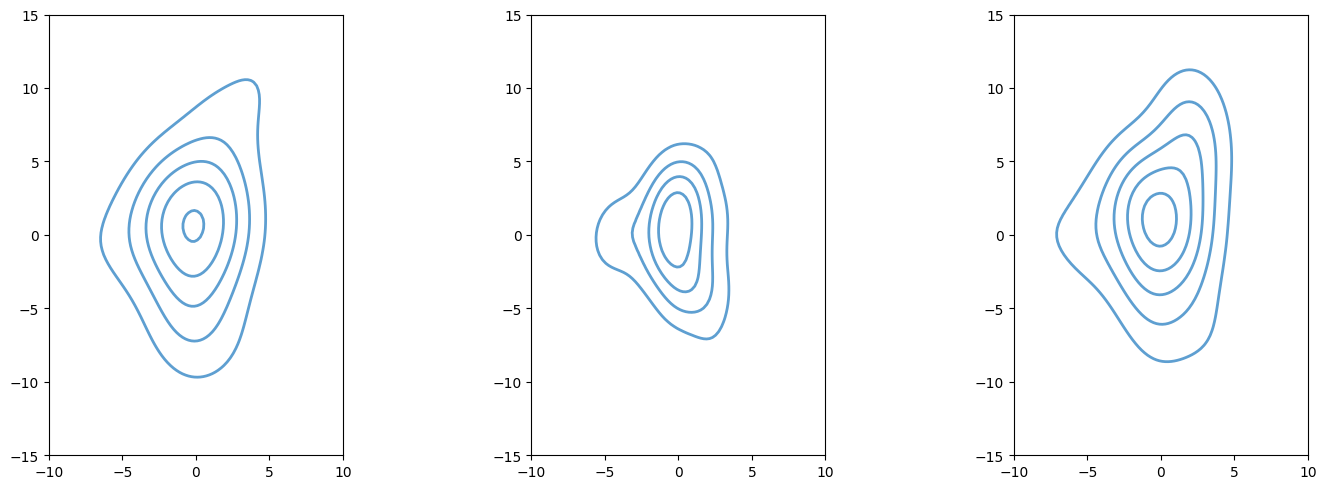

In [105]:
# Cell 4: 计算位置偏移并绘制核密度等高线图
from scipy.stats import gaussian_kde

# 计算第2、6、12个月相比第1个月的xy位置偏移
# 偏移矩阵形状: (3, 2, n_neuron)，其中3表示3个月份（2、6、12），2表示x和y维度

# 第1个月对应month_idx=0（参考月份）
# 第2、6、12个月对应month_idx=1, 5, 11
comparison_months = [1, 5, 11]  # 第2、6、12个月（0-based索引）
comparison_labels = ['Month 2', 'Month 6', 'Month 12']
reference_month_idx = 0  # 第1个月

# 计算偏移
n_comparison_months = len(comparison_months)
offset_matrix = np.zeros((n_comparison_months, 2, n_neuron), dtype=np.float32)  # (3, 2, n_neuron)

reference_positions = position[:, reference_month_idx, :]  # (n_neuron, 2)

for comp_idx, month_idx in enumerate(comparison_months):
    comparison_positions = position[:, month_idx, :]  # (n_neuron, 2)
    # 计算偏移：comparison - reference
    offsets = comparison_positions - reference_positions  # (n_neuron, 2)
    offset_matrix[comp_idx, :, :] = offsets.T  # 转置为(2, n_neuron)

print(f"位置偏移矩阵形状: {offset_matrix.shape}")
print(f"参考月份: 第1个月 (month_idx={reference_month_idx})")
print(f"比较月份: {comparison_labels}")

# 绘制核密度等高线图
fig, axes = plt.subplots(1, n_comparison_months, figsize=(15, 5))

for comp_idx, month_idx in enumerate(comparison_months):
    ax = axes[comp_idx]
    
    # 提取该月份的偏移数据
    offsets_x = offset_matrix[comp_idx, 0, :]  # x方向偏移
    offsets_y = offset_matrix[comp_idx, 1, :]  # y方向偏移
    
    # 只使用有效数据（非零或非NaN）
    valid_mask = ~(np.isnan(offsets_x) | np.isnan(offsets_y) | 
                   ((offsets_x == 0) & (offsets_y == 0)))
    
    # 统一设置坐标轴范围
    x_min, x_max = -10, 10
    y_min, y_max = -15, 15
    
    if np.sum(valid_mask) < 3:  # 至少需要3个点才能计算KDE
        ax.text(0.5, 0.5, 'Insufficient data', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(comparison_labels[comp_idx], fontsize=12)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel('X Offset (μm)', fontsize=10)
        ax.set_ylabel('Y Offset (μm)', fontsize=10)
        ax.set_aspect('equal', adjustable='box')
        continue
    
    offsets_x_valid = offsets_x[valid_mask]
    offsets_y_valid = offsets_y[valid_mask]
    
    # 计算核密度估计
    try:
        kde = gaussian_kde(np.vstack([offsets_x_valid, offsets_y_valid]))
    except:
        ax.text(0.5, 0.5, 'KDE computation failed', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(comparison_labels[comp_idx], fontsize=12)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel('X Offset (μm)', fontsize=10)
        ax.set_ylabel('Y Offset (μm)', fontsize=10)
        ax.set_aspect('equal', adjustable='box')
        continue
    
    # 创建网格用于绘制等高线（使用统一设置的范围）
    x_grid = np.linspace(x_min, x_max, 100)
    y_grid = np.linspace(y_min, y_max, 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    # 计算密度
    positions_grid = np.vstack([X.ravel(), Y.ravel()])
    density = kde(positions_grid).reshape(X.shape)
    
    # 绘制等高线图
    contour = ax.contour(X, Y, density, levels=5, colors='#5E9FD1', alpha=1, linewidths=2)
    #ax.contourf(X, Y, density, levels=20, cmap='Blues', alpha=0.7)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()

# 保存为PDF
output_pdf_path = f'{output_folder}/position_offset_kde.pdf'
plt.savefig(output_pdf_path, dpi=300, bbox_inches='tight')
print(f"位置偏移核密度等高线图已保存到: {output_pdf_path}")

plt.show()


距离统计:
  Month 2:
    Within-unit: 29 distances, mean=4.82 μm
    Across-unit: 71 distances, mean=47.18 μm
  Month 6:
    Within-unit: 29 distances, mean=3.42 μm
    Across-unit: 71 distances, mean=47.35 μm
  Month 12:
    Within-unit: 29 distances, mean=4.64 μm
    Across-unit: 71 distances, mean=47.00 μm

距离分布图已保存到: /media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim/distance_distribution_within_across.pdf


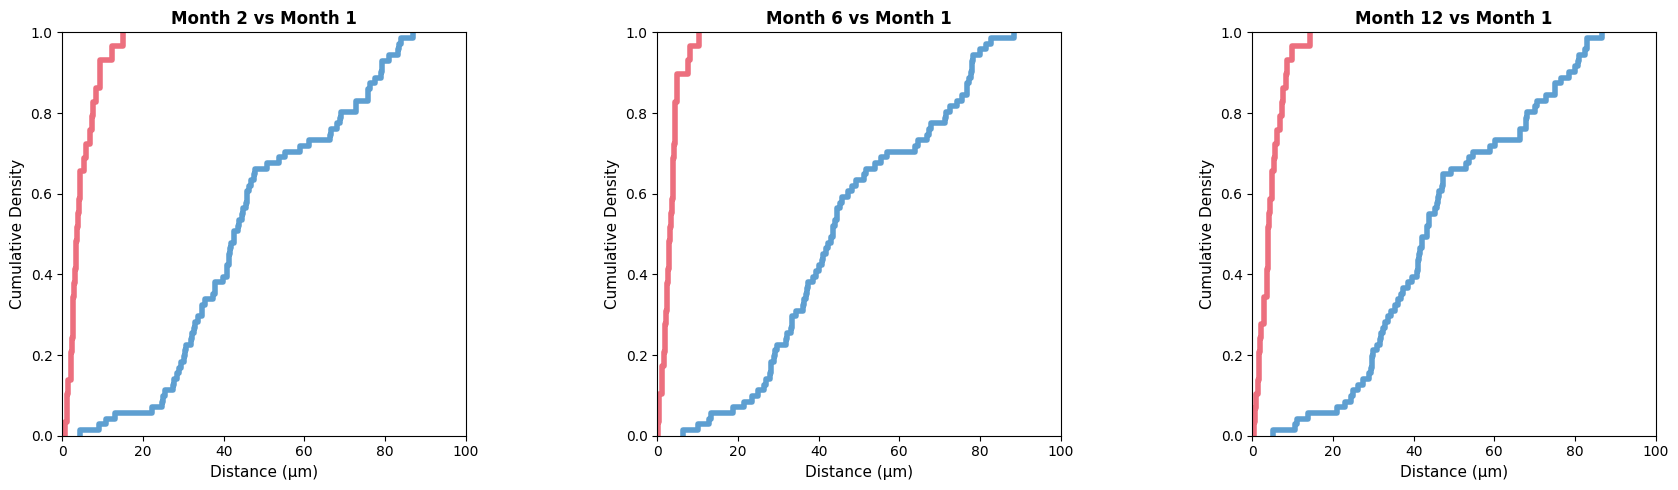

In [103]:
# Cell 5: 计算within-unit和across-unit距离分布
# 计算第2、6、12个月相比第1个月的位置偏移距离

comparison_months = [1, 5, 11]  # 第2、6、12个月（0-based索引）
comparison_labels = ['Month 2', 'Month 6', 'Month 12']
reference_month_idx = 0  # 第1个月

reference_positions = position[:, reference_month_idx, :]  # (n_neuron, 2)

# 计算within-unit距离：同一neuron在不同月份间的距离
within_unit_distances = []  # 列表，每个元素是(month_label, distances_list)

for comp_idx, month_idx in enumerate(comparison_months):
    comparison_positions = position[:, month_idx, :]  # (n_neuron, 2)
    
    # 计算每个neuron的位置偏移距离（欧氏距离）
    position_diffs = comparison_positions - reference_positions  # (n_neuron, 2)
    distances = np.sqrt(np.sum(position_diffs**2, axis=1))  # (n_neuron,)
    
    # 只保留有效距离（非NaN和非零）
    valid_mask = ~(np.isnan(distances) | (distances == 0))
    valid_distances = distances[valid_mask].tolist()
    
    within_unit_distances.append((comparison_labels[comp_idx], valid_distances))

# 定义5个组的坐标范围
groups = [
    ((0, 50), (0, 100), 'Group 1: x(0,50), y(0,100)'),
    ((150, 200), (200, 300), 'Group 2: x(150,200), y(200,300)'),
    ((300, 350), (400, 500), 'Group 3: x(300,350), y(400,500)'),
    ((450, 500), (200, 300), 'Group 4: x(450,500), y(200,300)'),
    ((600, 650), (0, 100), 'Group 5: x(600,650), y(0,100)')
]

# 计算across-unit距离：组内不同neuron之间的距离（只计算组内，组间不考虑）
# 对于每个比较月份，将neuron分配到组中，然后计算每个组内neuron对之间的距离
across_unit_distances = []  # 列表，每个元素是(month_label, distances_list)

for comp_idx, month_idx in enumerate(comparison_months):
    comparison_positions = position[:, month_idx, :]  # (n_neuron, 2)
    
    # 计算所有组内的neuron对之间的距离
    pair_distances = []
    
    # 对于每个组，计算组内neuron对之间的距离
    for (x_min, x_max), (y_min, y_max), group_label in groups:
        # 找出属于当前组的neuron索引
        group_neuron_indices = []
        for neuron_idx in range(n_neuron):
            pos = comparison_positions[neuron_idx, :]
            
            # 检查位置是否有效
            if np.any(np.isnan(pos)) or np.all(pos == 0):
                continue
            
            x_pos, y_pos = pos[0], pos[1]
            
            # 检查是否在当前组的范围内（x和y都要满足）
            if (x_min < x_pos < x_max) and (y_min < y_pos < y_max):
                group_neuron_indices.append(neuron_idx)
        
        # 计算该组内所有neuron对之间的距离
        n_group_neurons = len(group_neuron_indices)
        for i in range(n_group_neurons):
            for j in range(i + 1, n_group_neurons):
                neuron_i_idx = group_neuron_indices[i]
                neuron_j_idx = group_neuron_indices[j]
                
                pos_i = comparison_positions[neuron_i_idx, :]
                pos_j = comparison_positions[neuron_j_idx, :]
                
                dist = np.sqrt(np.sum((pos_i - pos_j)**2))
                if not np.isnan(dist) and dist > 0:
                    pair_distances.append(dist)
    
    across_unit_distances.append((comparison_labels[comp_idx], pair_distances))

print("距离统计:")
for comp_idx, month_label in enumerate(comparison_labels):
    within_dists = within_unit_distances[comp_idx][1]
    across_dists = across_unit_distances[comp_idx][1]
    print(f"  {month_label}:")
    print(f"    Within-unit: {len(within_dists)} distances, mean={np.mean(within_dists):.2f} μm")
    print(f"    Across-unit: {len(across_dists)} distances, mean={np.mean(across_dists):.2f} μm")

# 准备数据用于绘图（使用pandas DataFrame）
plot_data = []

for comp_idx, month_label in enumerate(comparison_labels):
    # Within-unit数据
    within_dists = within_unit_distances[comp_idx][1]
    for dist in within_dists:
        plot_data.append({
            'Distance (μm)': dist,
            'Type': 'Within-unit',
            'Month': month_label
        })
    
    # Across-unit数据
    across_dists = across_unit_distances[comp_idx][1]
    for dist in across_dists:
        plot_data.append({
            'Distance (μm)': dist,
            'Type': 'Across-unit',
            'Month': month_label
        })

df_plot = pd.DataFrame(plot_data)

# 绘制累积分布函数（CDF）
fig, axes = plt.subplots(1, len(comparison_months), figsize=(18, 5))

# 定义颜色
within_unit_color = '#EC6F7E'
across_unit_color = '#5E9FD1'
color_map = {
    'Within-unit': within_unit_color,
    'Across-unit': across_unit_color
}

for comp_idx, month_label in enumerate(comparison_labels):
    ax = axes[comp_idx]
    
    # 筛选该月份的数据
    df_month = df_plot[df_plot['Month'] == month_label]
    
    # 绘制within-unit和across-unit的累积分布
    for dist_type in ['Within-unit', 'Across-unit']:
        df_type = df_month[df_month['Type'] == dist_type]
        if len(df_type) > 0:
            # 使用ecdfplot绘制累积分布函数
            sns.ecdfplot(
                data=df_type,
                x='Distance (μm)',
                label=dist_type,
                ax=ax,
                color=color_map[dist_type],
                linewidth=4
            )
    
    ax.set_xlabel('Distance (μm)', fontsize=11)
    ax.set_ylabel('Cumulative Density', fontsize=11)
    ax.set_title(f'{month_label} vs Month 1', fontsize=12, fontweight='bold')
    ax.set_xlim([0, 100])  # 横轴范围0到100
    ax.set_ylim([0, 1])  # 纵轴范围0到1
    ax.set_aspect(100)  # 横纵轴1:1（x轴范围100，y轴范围1，所以aspect=100）

plt.tight_layout()

# 保存为PDF
output_pdf_path = f'{output_folder}/distance_distribution_within_across.pdf'
plt.savefig(output_pdf_path, dpi=300, bbox_inches='tight')
print(f"\n距离分布图已保存到: {output_pdf_path}")

plt.show()
